# 01 — Data Loading & EDA

Goal of this notebook:
1. Pull the **hERG** dataset from TDC's official `admet_group` (leaderboard-comparable split).
2. Lock the split to `data/splits.json` so every later notebook (1D/2D/3D/fusion) trains and evaluates on identical data.
3. Do enough EDA to catch problems (class imbalance, unparseable SMILES, huge molecules).

In [1]:
import sys
sys.path.append("..")  # so `from src...` works when running from notebooks/

import json
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from rdkit import Chem
from rdkit import RDLogger

from src.utils import set_seed, save_json

RDLogger.DisableLog("rdApp.*")  # silence RDKit's noisy parsing warnings for the EDA pass

with open("../config/data.yaml") as f:
    cfg = yaml.safe_load(f)

set_seed(cfg["seed"])
cfg


{'dataset': {'source': 'tdc_admet_group',
  'name': 'hERG',
  'data_path': '../data/raw',
  'dev_seed': 1},
 'splits': {'out_file': 'data/splits.json'},
 'seed': 42}

## Load via TDC's official ADMET benchmark group

In [2]:
Path(cfg["dataset"]["data_path"]).mkdir(parents=True, exist_ok=True)

from tdc.benchmark_group import admet_group
group = admet_group(path=cfg["dataset"]["data_path"])
benchmark = group.get(cfg["dataset"]["name"])

train_val = benchmark["train_val"]   # to be split into train/valid below
test = benchmark["test"]             # official held-out test set

print("train_val:", train_val.shape)
print("test:     ", test.shape)
train_val.head()


Found local copy...


train_val: (523, 3)
test:      (132, 3)


,Drug_ID,Drug,Y
0,DELAVIRDINE,CC(C)Nc1cccnc1N1CCN(C(=O)C2=CC3=C[C@H](NS(C)(=...,0.0
1,SOPHOCARPINE,O=C1C=CC[C@@H]2[C@H]3CCCN4CCC[C@H](CN12)[C@H]34,0.0
2,RALOXIFENE,O=C(c1ccc(OCC[NH+]2CCCCC2)cc1)c1c(-c2ccc(O)cc2...,0.0
3,N-DEMETHYLOLANZAPINE,Cc1cc2c(s1)Nc1ccccc1N=C2N1CCNCC1,1.0
4,SUNITINIB,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(F...,1.0


## Internal train/valid split (dev seed)

`get_train_valid_split` reproduces TDC's official scaffold-split procedure for a given seed —
same method the leaderboard uses, just one seed instead of the full 5.

In [3]:
dev_seed = cfg["dataset"]["dev_seed"]

train, valid = group.get_train_valid_split(
    benchmark=cfg["dataset"]["name"], split_type="default", seed=dev_seed
)

print("train:", train.shape)
print("valid:", valid.shape)
train.head()


generating training, validation splits...
100%|██████████| 523/523 [00:00<00:00, 1879.84it/s]

train: (457, 3)
valid: (66, 3)


,Drug_ID,Drug,Y
0,BMCL20031829_02,O=C1NCCN1CCN1CC=C(c2cn(-c3ccc(F)cc3)c3ccc(Cl)c...,1.0
1,VARDENAFIL,CCCc1nc(C)c2c(=O)nc(-c3cc(S(=O)(=O)N4CC[NH+](C...,1.0
2,ISRADIPINE,COC(=O)C1=C(C)NC(C)=C(C(=O)OC(C)C)[C@H]1c1cccc...,0.0
3,WOMBAT11,N#Cc1ccc(Cn2cncc2C[NH2+][C@@H]2CCN(C(=O)c3cccn...,1.0
4,WOMBAT66,N#Cc1ccc(Cn2cncc2C[NH2+][C@@H]2CCN(C(=O)c3cncc...,1.0


## Sanity checks before locking the split

Check: label column name, class balance in each split, and that every SMILES parses in RDKit — anything that fails to parse now will silently break conformer generation.

In [4]:
for name, df in [("train", train), ("valid", valid), ("test", test)]:
    print(f"{name:6s}  n={len(df):4d}  positive_rate={df['Y'].mean():.3f}")


train   n= 457  positive_rate=0.665
valid   n=  66  positive_rate=0.758
test    n= 132  positive_rate=0.735


In [5]:
def parse_rate(df, smiles_col="Drug"):
    ok = df[smiles_col].apply(lambda s: Chem.MolFromSmiles(s) is not None)
    bad = df[~ok]
    return ok.mean(), bad

for name, df in [("train", train), ("valid", valid), ("test", test)]:
    rate, bad = parse_rate(df)
    print(f"{name:6s}  RDKit-parseable: {rate:.4f}  ({len(bad)} unparseable)")
    if len(bad):
        display(bad)


train   RDKit-parseable: 1.0000  (0 unparseable)
valid   RDKit-parseable: 1.0000  (0 unparseable)
test    RDKit-parseable: 1.0000  (0 unparseable)


## Molecule size distribution

In [6]:
def heavy_atoms(smiles):
    m = Chem.MolFromSmiles(smiles)
    return m.GetNumHeavyAtoms() if m else np.nan

all_df = pd.concat([train.assign(split="train"), valid.assign(split="valid"), test.assign(split="test")])
all_df["n_heavy_atoms"] = all_df["Drug"].apply(heavy_atoms)

all_df["n_heavy_atoms"].describe()


count    655.000000
mean      26.479389
std        8.303998
min        7.000000
25%       21.000000
50%       26.000000
75%       31.000000
max       74.000000
Name: n_heavy_atoms, dtype: float64

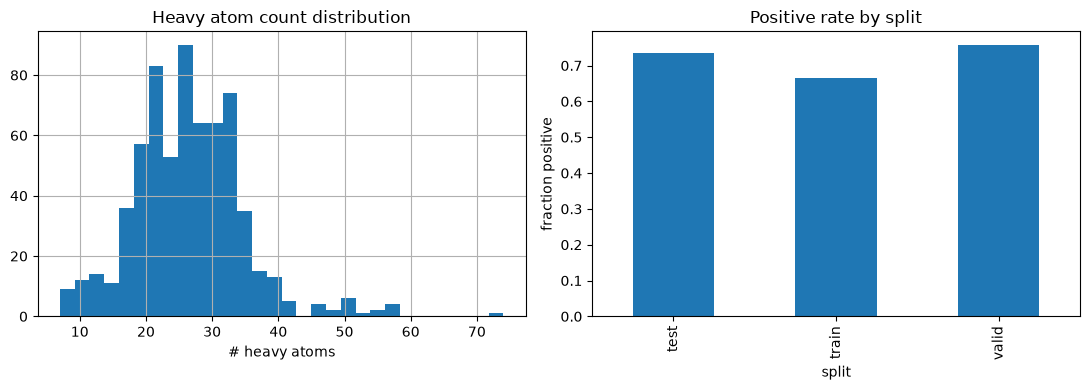

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
all_df["n_heavy_atoms"].hist(bins=30, ax=axes[0])
axes[0].set_title("Heavy atom count distribution")
axes[0].set_xlabel("# heavy atoms")

all_df.groupby("split")["Y"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Positive rate by split")
axes[1].set_ylabel("fraction positive")
plt.tight_layout()
plt.show()


## Lock the split to disk

Everything downstream (1D/2D/3D/fusion notebooks) reads from `data/splits.json` — nothing after this cell should call `get_train_valid_split` again.

In [8]:
splits_out = {
    "dataset": cfg["dataset"]["name"],
    "dev_seed": dev_seed,
    "train": {"smiles": train["Drug"].tolist(), "y": train["Y"].tolist(), "id": train["Drug_ID"].tolist()},
    "valid": {"smiles": valid["Drug"].tolist(), "y": valid["Y"].tolist(), "id": valid["Drug_ID"].tolist()},
    "test":  {"smiles": test["Drug"].tolist(),  "y": test["Y"].tolist(),  "id": test["Drug_ID"].tolist()},
}

save_json(splits_out, Path("..") / cfg["splits"]["out_file"])
print("Saved:", Path("..") / cfg["splits"]["out_file"])
print({k: len(v["smiles"]) for k, v in splits_out.items() if isinstance(v, dict)})


Saved: ..\data\splits.json
{'train': 457, 'valid': 66, 'test': 132}
